# 03 — Error Analysis

Detailed analysis of the tagger's errors:
- Most common confusion pairs
- Error rate by tag
- Hardest words (most frequently mis-tagged)
- Error examples with context

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

from src.parser import parse_conllu, get_forms_and_tags
from src.lexicon import Lexicon
from src.tagger import RuleBasedTagger
from src.evaluate import Evaluator, UPOS_TAGS

plt.rcParams['figure.figsize'] = (14, 8)
sns.set_style('whitegrid')

In [2]:
# Load and tag
train_sents = parse_conllu('../data/en_ewt-ud-train.conllu')
dev_sents = parse_conllu('../data/en_ewt-ud-dev.conllu')

lexicon = Lexicon().build(train_sents)
tagger = RuleBasedTagger(lexicon)

dev_corpus = get_forms_and_tags(dev_sents)
dev_tagged = tagger.tag_corpus(dev_corpus)

acc = Evaluator.accuracy(dev_tagged)
print(f'Dev accuracy: {acc:.4f}')

Dev accuracy: 0.8722


## 1. Most Common Confusion Pairs

In [3]:
# Collect all errors
confusion_pairs = Counter()
error_words = defaultdict(list)

for words, gold, pred in dev_tagged:
    for w, g, p in zip(words, gold, pred):
        if g != p:
            confusion_pairs[(g, p)] += 1
            error_words[(g, p)].append(w)

print(f'Total error types (gold→pred pairs): {len(confusion_pairs)}')
print(f'\nTop 20 confusion pairs:')
print(f'{"Gold":<8} {"Pred":<8} {"Count":>7}  Example words')
print('-' * 60)
for (g, p), count in confusion_pairs.most_common(20):
    examples = ', '.join(list(set(error_words[(g, p)]))[:5])
    print(f'{g:<8} {p:<8} {count:>7}  {examples}')

Total error types (gold→pred pairs): 120

Top 20 confusion pairs:
Gold     Pred       Count  Example words
------------------------------------------------------------
PROPN    NOUN         470  Britt, Agency, Sources, line, School
VERB     AUX          258  's, do, have, been, Have
VERB     NOUN         211  demand, type, Retire, building, travel
ADP      PART         198  to, TO, ta
NOUN     VERB         197  birding, fight, sit, stop, launch
NOUN     PROPN        164  museum, prophet, CES, 3G, court
SCONJ    ADP          133  after, Like, with, With, as
ADV      ADP          122  as, around, up, As, out
ADJ      NOUN         100  top, touch, dodgy, creme, infertile
PRON     SCONJ         93  That, that
PART     AUX           83  s, 's
ADJ      VERB          69  steep, lead, embarrassed, satisfying, gratifying
ADJ      DET           57  much, Several, Many, enough, many
NOUN     ADJ           54  Moral, middle, transmittal, professional, memorial
NUM      NOUN          54  07:17, 10:

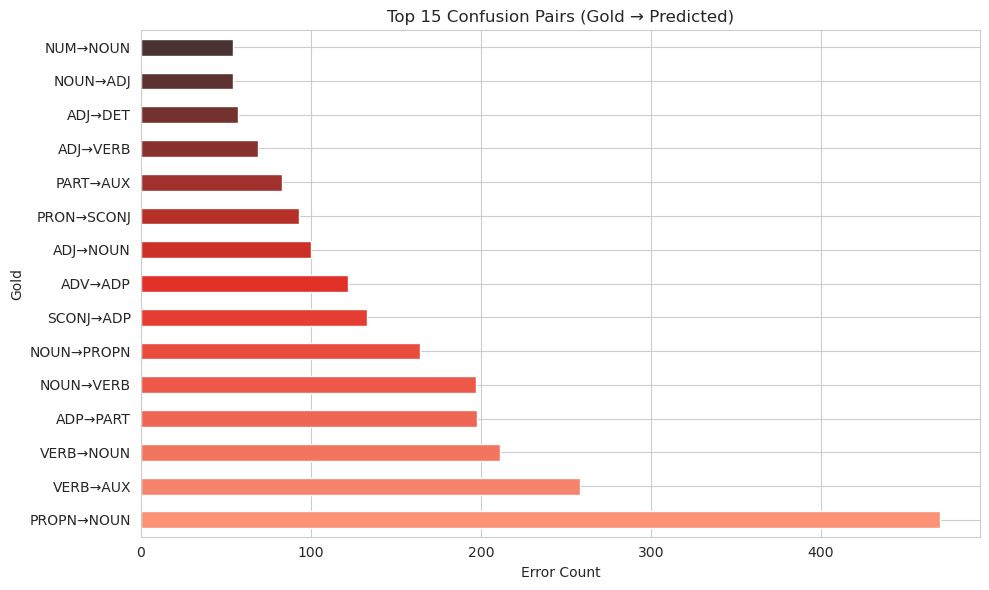

In [4]:
# Confusion pairs heatmap (top errors)
top_pairs = confusion_pairs.most_common(15)
pair_df = pd.DataFrame([(g, p, c) for (g, p), c in top_pairs],
                       columns=['Gold', 'Predicted', 'Count'])

fig, ax = plt.subplots(figsize=(10, 6))
pair_df_pivot = pair_df.set_index(['Gold', 'Predicted'])['Count'].unstack(fill_value=0)
pair_df.plot(kind='barh', x='Gold', y='Count', ax=ax, color=sns.color_palette('Reds_d', 15),
             legend=False)
labels = [f'{g}→{p}' for g, p in zip(pair_df['Gold'], pair_df['Predicted'])]
ax.set_yticklabels(labels)
ax.set_xlabel('Error Count')
ax.set_title('Top 15 Confusion Pairs (Gold → Predicted)')
plt.tight_layout()
plt.savefig('../outputs/top_confusion_pairs.png', dpi=150)
plt.show()

## 2. Per-Tag Error Rate

In [5]:
# Error rate per gold tag
tag_total = Counter()
tag_errors = Counter()

for words, gold, pred in dev_tagged:
    for g, p in zip(gold, pred):
        tag_total[g] += 1
        if g != p:
            tag_errors[g] += 1

error_rates = {}
for tag in UPOS_TAGS:
    total = tag_total.get(tag, 0)
    errs = tag_errors.get(tag, 0)
    error_rates[tag] = errs / total if total > 0 else 0

df_err = pd.DataFrame({
    'Tag': list(error_rates.keys()),
    'Error Rate': list(error_rates.values()),
    'Total': [tag_total.get(t, 0) for t in error_rates],
    'Errors': [tag_errors.get(t, 0) for t in error_rates],
}).sort_values('Error Rate', ascending=False)

print(df_err.to_string(index=False))

  Tag  Error Rate  Total  Errors
    X    0.932203     59      55
  SYM    0.617284     81      50
SCONJ    0.380353    397     151
PROPN    0.296733   1867     554
 INTJ    0.295652    115      34
  ADV    0.257305   1232     317
 VERB    0.201699   2707     546
  ADJ    0.165147   1865     308
  NUM    0.143603    383      55
 PART    0.132921    647      86
 NOUN    0.122803   4210     517
  ADP    0.110893   2038     226
 PRON    0.069213   2225     154
  DET    0.038947   1900      74
CCONJ    0.034660    779      27
PUNCT    0.015935   3075      49
  AUX    0.007020   1567      11


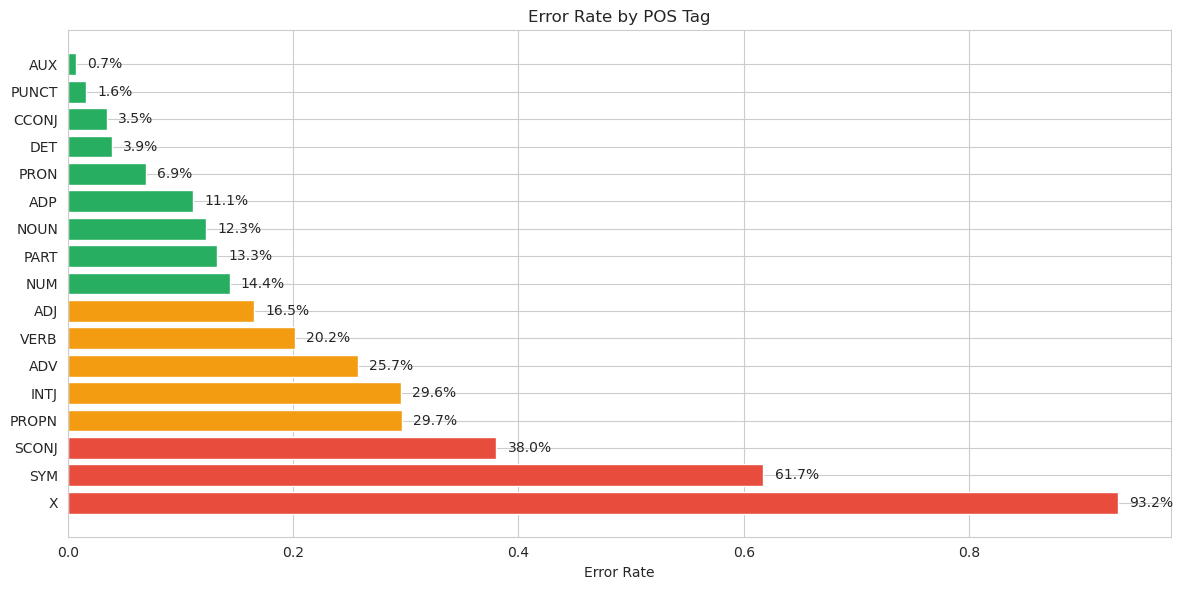

In [6]:
# Error rate bar chart
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if r > 0.3 else '#f39c12' if r > 0.15 else '#27ae60'
          for r in df_err['Error Rate']]
ax.barh(df_err['Tag'], df_err['Error Rate'], color=colors)
ax.set_xlabel('Error Rate')
ax.set_title('Error Rate by POS Tag')
for i, (rate, tag) in enumerate(zip(df_err['Error Rate'], df_err['Tag'])):
    ax.text(rate + 0.01, i, f'{rate:.1%}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/error_rate_by_tag.png', dpi=150)
plt.show()

## 3. Hardest Words

In [7]:
# Words with most errors
word_errors = Counter()
word_total = Counter()

for words, gold, pred in dev_tagged:
    for w, g, p in zip(words, gold, pred):
        word_total[w.lower()] += 1
        if g != p:
            word_errors[w.lower()] += 1

# Words with at least 3 occurrences
hard_words = []
for word, errs in word_errors.most_common(50):
    total = word_total[word]
    if total >= 3:
        hard_words.append({
            'word': word,
            'errors': errs,
            'total': total,
            'error_rate': errs / total,
        })

df_hard = pd.DataFrame(hard_words[:30])
print('Top 30 hardest words (by error count, min 3 occurrences):')
print(df_hard.to_string(index=False))

Top 30 hardest words (by error count, min 3 occurrences):
  word  errors  total  error_rate
    to     206    561    0.367201
  that     111    201    0.552239
  have      97    176    0.551136
    's      73    120    0.608333
    as      55     91    0.604396
    no      41     49    0.836735
  this      40    139    0.287770
  like      38     68    0.558824
    do      35    108    0.324074
   had      32     43    0.744186
thanks      31     31    1.000000
 there      29     86    0.337209
   for      28    241    0.116183
 about      28     64    0.437500
  well      25     29    0.862069
   has      25     77    0.324675
     s      22     43    0.511628
   are      21    155    0.135484
    us      20     34    0.588235
   out      20     50    0.400000
  much      20     20    1.000000
     /      19     29    0.655172
    of      18    388    0.046392
    in      18    365    0.049315
 debra      18     19    0.947368
  work      17     34    0.500000
    is      17    333   

## 4. Known vs Unknown Word Accuracy

In [8]:
# Split accuracy: known (in lexicon) vs unknown words
known_correct, known_total = 0, 0
unknown_correct, unknown_total = 0, 0

for words, gold, pred in dev_tagged:
    for w, g, p in zip(words, gold, pred):
        if lexicon.lookup(w) is not None:
            known_total += 1
            if g == p:
                known_correct += 1
        else:
            unknown_total += 1
            if g == p:
                unknown_correct += 1

print(f'Known words  : {known_correct:,}/{known_total:,} = {known_correct/known_total:.4f}')
print(f'Unknown words: {unknown_correct:,}/{unknown_total:,} = {unknown_correct/unknown_total:.4f}')
print(f'Overall      : {known_correct+unknown_correct:,}/{known_total+unknown_total:,} = {(known_correct+unknown_correct)/(known_total+unknown_total):.4f}')

Known words  : 20,867/23,438 = 0.8903
Unknown words: 1,066/1,709 = 0.6238
Overall      : 21,933/25,147 = 0.8722


In [9]:
# Save error analysis
errors_list = Evaluator.error_examples(dev_tagged, max_per_pair=20)
df_errors = pd.DataFrame(errors_list)
df_errors.to_csv('../outputs/error_analysis.csv', index=False)
print(f'Saved {len(df_errors)} error examples to outputs/error_analysis.csv')

Saved 1044 error examples to outputs/error_analysis.csv
